# 10 - Laboratorio de OCR e Investigación Crítica con IA

**Materiales desarrollados por Matías Barreto, 2026**

**Tecnicatura Superior en Ciencias de Datos e IA, IFTS24**
* **Nomenclatura Oficial:** Procesamiento Digital de Imágenes
* **Nombre de Trabajo:** Laboratorio de Tecnologías de la Imagen Digital

---

## Objetivo

El objetivo de este laboratorio es investigar de manera crítica el problema de OCR en español utilizando fuentes técnicas, modelos preentrenados y herramientas de IA generativa, pero sin delegar el criterio de validación en el LLM. Vamos a usar OCR como caso concreto para desarrollar una competencia más amplia: buscar información, verificarla, discriminarla y convertirla en decisiones técnicas justificadas.

## Resultados de aprendizaje

Al final de este notebook van a poder:
1. Auditar afirmaciones técnicas producidas por un LLM utilizando fuentes primarias.
2. Distinguir entre información correcta, incorrecta, imprecisa, desactualizada y no verificable.
3. Implementar un pipeline básico de OCR en Python a partir de información validada.
4. Justificar la elección de un modelo en función del hardware disponible, el tipo de documento y la calidad de la documentación.
5. Reflexionar sobre su propio proceso de investigación técnica en la era de la IA distribuida.

## Terminología clave (Microglosario)

* **OCR (Reconocimiento Óptico de Caracteres):** Técnica que permite extraer texto a partir de imágenes, escaneos o fotografías de documentos.
* **Fuente primaria:** Recurso técnico original donde una afirmación puede verificarse directamente, por ejemplo la documentación oficial, el repositorio de un modelo o un paper.
* **Handle de modelo:** Identificador exacto con el que un modelo se publica en plataformas como ✦ 🤗 Hugging Face.
* **Pipeline:** Abstracción de `transformers` que simplifica la carga del modelo, el preprocesamiento y la inferencia.
* **CER / WER:** Métricas de error para comparar el texto reconocido con un texto de referencia. CER mide error por carácter y WER por palabra.
* **Trazabilidad:** Registro explícito de qué consultaron, qué fuente usaron, qué verificaron y qué decisión tomaron.

## ¿Por qué existe esta actividad?

Esta actividad surgió a partir de una pregunta de cursada: **"¿acaso no veremos OCR?"**. La respuesta de este laboratorio no es dar una clase cerrada con respuestas prefabricadas, sino abrir un espacio de investigación guiada.

Hoy ustedes tienen acceso simultáneo a LLMs, papers, repositorios, foros, documentación oficial, videos, Spaces y datasets. Eso amplía muchísimo las posibilidades de aprendizaje, pero también instala un problema nuevo: **tener acceso no equivale a saber investigar**.

En este cuaderno vamos a trabajar una idea central para su formación técnica: en la era de la disponibilidad distribuida, una competencia fundamental consiste en saber buscar, discriminar, contrastar y justificar información antes de convertirla en código o en una decisión de desarrollo.

OCR es el caso de estudio. La investigación crítica es el verdadero contenido de fondo.

## Protocolo mínimo de investigación técnica

Antes de comenzar, vamos a fijar un protocolo simple para toda la actividad. Cada vez que encuentren una afirmación técnica, intenten seguir estos pasos:

1. Extraer una afirmación verificable.
2. Identificar cuál sería la fuente primaria adecuada para auditarla.
3. Buscar evidencia directa.
4. Clasificar la afirmación como `correcta`, `incorrecta`, `imprecisa`, `desactualizada` o `no verificable`.
5. Registrar qué decisión técnica tomarían a partir de esa verificación.

Este protocolo no sirve solo para OCR. También sirve para cualquier tema nuevo que necesiten investigar en sus propios desarrollos.

## Movimiento 1 - ¿Qué dice la máquina?

**Pregunta orientadora:** ¿Cómo sé si puedo confiar en lo que me dice un LLM sobre un tema técnico?

En este primer movimiento el LLM no ocupa el lugar de autoridad. Lo vamos a tratar como una fuente inicial de trabajo que debe ser auditada. El objetivo es construir un criterio de verificación apoyado en evidencia.

> **Fuente: respuesta generada por un LLM. Fecha de consulta: mayo 2025.**
>
> En Hugging Face, la tarea de OCR no tiene un único tag exclusivo, sino que se aborda principalmente bajo dos categorías clave:
> - `image-to-text`: tag principal para modelos que toman una imagen y generan texto secuencial.
> - `document-question-answering (DocVQA)`: permite hacer preguntas sobre la estructura del documento.
>
> Modelos recomendados:
> - Microsoft TrOCR (`microsoft/trocr-base-handwritten` o `printed`): encoder de visión (ViT) + decoder de texto (GPT-2). Transformer puro para OCR.
> - Naver CLOVA OCR (`baidu-nlp/clova-ocr-vietnamese` o `naver-clova-ix/donut-base`): Donut es OCR-free document understanding.
> - Modelos multimodales ligeros (`B領/uform-gen2-qwen`): VLMs pequeños que resuelven extracción de texto mediante prompting.
>
> Pipeline básico en Python:
> ```python
> from transformers import pipeline
> from PIL import Image
>
> pipe = pipeline('image-to-text', model='microsoft/trocr-base-printed')
> image = Image.open('tu_documento.png')
> result = pipe(image)
> print(result['generated_text'])
> ```

### Consignas de trabajo

1. Lean el texto anterior e identifiquen al menos cinco afirmaciones verificables.
2. Para cada afirmación, decidan qué fuente primaria conviene consultar primero.
3. Verifiquen cada afirmación usando evidencia directa.
4. Completen una tabla con las columnas: `Afirmación | Fuente consultada | Resultado | Evidencia | Decisión técnica`.
5. Escriban un párrafo breve donde registren qué fue fácil de verificar, qué fue difícil y qué estrategia de búsqueda usaron.

**Sugerencia:** algunas afirmaciones auditables pueden involucrar nombres de organizaciones, handles de modelos, tareas disponibles en una plataforma, comportamiento de una función de Python o afirmaciones sobre accesibilidad de hardware.

### Fuentes primarias sugeridas

Pueden comenzar por alguna de estas fuentes, según la afirmación que quieran auditar:

* Página oficial del modelo en ✦ 🤗 Hugging Face.
* Documentación oficial de `transformers`.
* Paper original del modelo.
* Repositorio oficial del proyecto.
* Espacios de demostración mantenidos por la organización autora.
* Documentación oficial de Tesseract, EasyOCR o PaddleOCR si comparan alternativas.

Eviten usar una única fuente secundaria como respaldo total. Si una afirmación afecta una decisión de implementación, intenten contrastarla con al menos dos evidencias.

In [ ]:
import pandas as pd

print("✦ Preparando una tabla base para registrar la auditoría técnica...")

datos_verificacion = [
    {
        "Afirmación": "En Hugging Face, OCR puede abordarse mediante la tarea image-to-text.",
        "Fuente consultada": "Página oficial de Hugging Face: Tasks / Image-to-Text. https://huggingface.co/tasks/image-to-text",
        "Resultado": "Verdadero",
        "Evidencia": "La tarea image-to-text consiste en generar texto a partir de una imagen, lo cual coincide con el objetivo básico del OCR.",
        "Decisión técnica": "Es una categoría adecuada para buscar modelos OCR."
    },
    {
        "Afirmación": "document-question-answering permite hacer preguntas sobre documentos.",
        "Fuente consultada": "Página oficial de Hugging Face: Tasks / Document Question Answering. https://huggingface.co/tasks/document-question-answering",
        "Resultado": "Verdadero",
        "Evidencia": "La tarea permite responder preguntas a partir de imágenes de documentos.",
        "Decisión técnica": "No es OCR puro: sirve más para comprensión de documentos."
    },
    {
        "Afirmación": "Microsoft TrOCR es un modelo recomendado para OCR.",
        "Fuente consultada": "Ficha oficial del modelo microsoft/trocr-base-printed en Hugging Face",
        "Resultado": "Verdadero",
        "Evidencia": "La ficha del modelo lo presenta como un modelo Transformer para reconocimiento óptico de caracteres.",
        "Decisión técnica": "Aceptar como alternativa válida para OCR."
    },
    {
        "Afirmación": "TrOCR usa una arquitectura encoder-decoder.",
        "Fuente consultada": "Documentación/ficha oficial de Microsoft TrOCR",
        "Resultado": "Verdadero",
        "Evidencia": "La descripción del modelo indica que combina un encoder de imagen con un decoder de texto.",
        "Decisión técnica": "Es relevante para entender cómo transforma imagen en texto."
    },
    {
        "Afirmación": "Los VLMs pueden resolver tareas de extracción de texto mediante prompting.",
        "Fuente consultada": "Documentación de modelos image-text-to-text / vision-language models",
        "Resultado": "Parcialmente verdadero",
        "Evidencia": "Los VLMs pueden recibir imagen y texto como entrada, pero no todos están especializados en OCR.",
        "Decisión técnica": "Los VLMs pueden ser útiles para leer o interpretar imágenes, pero si se necesita extraer texto con mucha precisión, conviene usar también una herramienta especializada en OCR."
    },
    {
         "Afirmación": "Donut es un modelo para comprensión de documentos que funciona sin una etapa OCR tradicional separada.",
         "Fuente consultada": "Paper original de Donut y ficha oficial del modelo naver-clova-ix/donut-base en Hugging Face",
         "Resultado": "Verdadero",
         "Evidencia": "Donut recibe directamente la imagen del documento y genera una salida en texto o estructura, sin requerir que primero se extraiga todo el texto mediante un OCR externo.",
         "Decisión técnica": "Es una alternativa útil para tareas de comprensión de documentos, aunque no debe confundirse con un OCR clásico que solo copia texto."
    }
]

tabla_verificacion = pd.DataFrame(datos_verificacion)

print("✓ Tabla de verificación completa.")
tabla_verificacion

✦ Preparando una tabla base para registrar la auditoría técnica...
✓ Tabla de verificación completa.


,Afirmación,Fuente consultada,Resultado,Evidencia,Decisión técnica
0,"En Hugging Face, OCR puede abordarse mediante ...",Página oficial de Hugging Face: Tasks / Image-...,Verdadero,La tarea image-to-text consiste en generar tex...,Es una categoría adecuada para buscar modelos ...
1,document-question-answering permite hacer preg...,Página oficial de Hugging Face: Tasks / Docume...,Verdadero,La tarea permite responder preguntas a partir ...,No es OCR puro: sirve más para comprensión de ...
2,Microsoft TrOCR es un modelo recomendado para ...,Ficha oficial del modelo microsoft/trocr-base-...,Verdadero,La ficha del modelo lo presenta como un modelo...,Aceptar como alternativa válida para OCR.
3,TrOCR usa una arquitectura encoder-decoder.,Documentación/ficha oficial de Microsoft TrOCR,Verdadero,La descripción del modelo indica que combina u...,Es relevante para entender cómo transforma ima...
4,Los VLMs pueden resolver tareas de extracción ...,Documentación de modelos image-text-to-text / ...,Parcialmente verdadero,Los VLMs pueden recibir imagen y texto como en...,Los VLMs pueden ser útiles para leer o interpr...
5,Donut es un modelo para comprensión de documen...,Paper original de Donut y ficha oficial del mo...,Verdadero,Donut recibe directamente la imagen del docume...,Es una alternativa útil para tareas de compren...


## Consigna de Lectura e Interpretación

Mientras verifican, deténganse en estas preguntas:

1. ¿Todas las afirmaciones equivocadas son igual de graves para un desarrollo real?
2. ¿Qué diferencia encontraron entre un dato incorrecto, uno impreciso y uno no verificable?
3. Si un handle está mal escrito pero la idea general parece razonable, ¿alcanza con eso para implementarlo? ¿Por qué?

## Movimiento 2 - ¿Qué puedo construir?

**Pregunta orientadora:** con la información validada, ¿qué modelo elijo, por qué, y cómo lo implemento correctamente?

En este movimiento el objetivo ya no es solo verificar, sino transformar información validada en una implementación funcional. El LLM puede volver a aparecer como herramienta de exploración, pero cada consulta debe quedar registrada y controlada por ustedes.

### Consignas de implementación

1. Elijan un modelo que haya sobrevivido a la auditoría del movimiento 1.
2. Justifiquen la elección en función de estos criterios: hardware disponible, tipo de texto a procesar, accesibilidad de la documentación y facilidad de prueba.
3. Implementen un pipeline de OCR corregido.
4. Prueben el pipeline con al menos dos imágenes: una de texto impreso y otra manuscrita o degradada.
5. Comparen los resultados e identifiquen al menos una limitación del modelo elegido.
6. Si usan un LLM para pedir ayuda con código, registren la consulta exacta, el resultado y la verificación posterior.
7. De manera optativa, comparen con un segundo enfoque como Tesseract, EasyOCR o PaddleOCR.

### Paso manual antes de automatizar

Antes de correr modelos complejos, describan manualmente qué esperan que ocurra en un sistema de OCR:

1. Entra una imagen.
2. El sistema detecta patrones visuales que podrían corresponder a caracteres o regiones de texto.
3. El modelo produce una secuencia textual estimada.
4. Esa salida puede contener omisiones, sustituciones, signos mal resueltos o problemas de segmentación.

Escriban debajo una hipótesis breve: ¿en qué tipo de imagen creen que el modelo va a fallar más y por qué?

In [8]:
print("✦ Instalando dependencias mínimas para explorar OCR con Hugging Face...")
!pip install transformers torch pillow matplotlib pandas -q
print("✓ Dependencias listas.")

✦ Instalando dependencias mínimas para explorar OCR con Hugging Face...
✓ Dependencias listas.


In [9]:
from transformers import pipeline
from PIL import Image
import matplotlib.pyplot as plt
from pathlib import Path

print("✓ Librerías importadas correctamente.")

✓ Librerías importadas correctamente.


### Registro de decisión técnica

Completen este bloque antes de ejecutar el modelo:

* **Modelo elegido:** microsoft/trocr-base-handwritten
* **Fuente primaria que validó el handle:** La página oficial del modelo en Hugging Face, dentro de la organización Microsoft. Allí se identifica el modelo como microsoft/trocr-base-handwritten y se indica que pertenece a la familia TrOCR.
* **Tipo de documento para el que parece más apropiado:** Este modelo parece más apropiado para imágenes con texto manuscrito, especialmente líneas o fragmentos breves de escritura a mano. Lo elegí porque una de las pruebas del trabajo práctico incluye una imagen manuscrita o degradada.

* **Ventaja principal:** se puede cargar directamente desde Hugging Face y probar en Colab sin entrenar un modelo desde cero.
* **Limitación esperada:** Una limitación esperada es que el modelo puede fallar cuando la imagen tiene baja calidad, ruido, mala iluminación, texto inclinado, letra muy irregular o contenido en un idioma distinto del esperado. También puede tener peor desempeño en texto impreso, porque el modelo elegido está orientado específicamente a manuscritos.
* **Razón por la que lo eligieron por sobre otras alternativas:** Lo elegí porque se adapta mejor al objetivo de probar OCR con redes neuronales sobre texto manuscrito. En comparación con microsoft/trocr-base-printed, este modelo es más coherente con la imagen manuscrita usada en la prueba. También resulta más simple de implementar en Colab que entrenar un modelo propio o configurar herramientas externas como Tesseract o EasyOCR.

In [18]:
print("✦ Definiendo el modelo elegido para la prueba de OCR...")

nombre_modelo = "microsoft/trocr-base-handwritten"

print(f"Modelo configurado: {nombre_modelo}")
print("Si validaron otro modelo, reemplacen el handle en esta celda antes de continuar.")
import torch
from transformers import TrOCRProcessor, VisionEncoderDecoderModel

print("✦ Definiendo el modelo elegido para la prueba de OCR...")

nombre_modelo = "microsoft/trocr-base-handwritten"

print(f"Modelo configurado: {nombre_modelo}")

processor_ocr = TrOCRProcessor.from_pretrained(nombre_modelo)

modelo_ocr = VisionEncoderDecoderModel.from_pretrained(
    nombre_modelo
)

dispositivo = "cuda" if torch.cuda.is_available() else "cpu"
modelo_ocr.to(dispositivo)

print(f"✓ Modelo de OCR cargado correctamente en: {dispositivo}")



✦ Definiendo el modelo elegido para la prueba de OCR...
Modelo configurado: microsoft/trocr-base-handwritten
Si validaron otro modelo, reemplacen el handle en esta celda antes de continuar.
✦ Definiendo el modelo elegido para la prueba de OCR...
Modelo configurado: microsoft/trocr-base-handwritten


Loading weights:   0%|          | 0/478 [00:00<?, ?it/s]

[transformers] VisionEncoderDecoderModel LOAD REPORT from: microsoft/trocr-base-handwritten
Key                         | Status  | 
----------------------------+---------+-
encoder.pooler.dense.bias   | MISSING | 
encoder.pooler.dense.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


✓ Modelo de OCR cargado correctamente en: cpu


### Preparación de imágenes de prueba

Para esta actividad conviene trabajar con dos imágenes contrastantes. Pueden usar archivos propios o descargar muestras desde una fuente confiable. La recomendación es registrar siempre de dónde salió cada imagen.

Sugerencia de organización:

* `imagen_impresa.png`
* `imagen_mano.png`

Si no tienen imágenes propias, creen una carpeta local llamada `ocr_muestras/` y guarden allí las dos muestras que vayan a usar.

In [19]:
from pathlib import Path
from google.colab import files
import shutil

# 1. Crear carpeta
carpeta_muestras = Path("/content/ocr_muestras")
carpeta_muestras.mkdir(exist_ok=True)

print("✦ Carpeta de trabajo para muestras lista.")

# 2. Subir las imágenes
print("Seleccioná imagen_impresa.png e imagen_mano.png:")
archivos_subidos = files.upload()

# 3. Mover las imágenes a la carpeta
for nombre_archivo in archivos_subidos:
    origen = Path("/content") / nombre_archivo
    destino = carpeta_muestras / nombre_archivo

    if destino.exists():
        destino.unlink()

    shutil.move(str(origen), str(destino))

# 4. Definir las rutas
ruta_imagen_impresa = carpeta_muestras / "imagen_impresa.png"
ruta_imagen_mano = carpeta_muestras / "imagen_mano.jpg"

# 5. Mostrar resultado
print("\n✓ Archivos preparados:")
print(f"Imagen impresa: {ruta_imagen_impresa}")
print(f"Imagen manuscrita o degradada: {ruta_imagen_mano}")

print("\nValidación:")
print("Imagen impresa encontrada:", ruta_imagen_impresa.exists())
print("Imagen manuscrita encontrada:", ruta_imagen_mano.exists())

✦ Carpeta de trabajo para muestras lista.
Seleccioná imagen_impresa.png e imagen_mano.png:


Saving imagen_impresa.png to imagen_impresa.png
Saving imagen_mano.jpg to imagen_mano.jpg

✓ Archivos preparados:
Imagen impresa: /content/ocr_muestras/imagen_impresa.png
Imagen manuscrita o degradada: /content/ocr_muestras/imagen_mano.jpg

Validación:
Imagen impresa encontrada: True
Imagen manuscrita encontrada: True


In [12]:
from PIL import Image

print("✦ Intentando abrir las imágenes de prueba...")

if not ruta_imagen_impresa.exists():
    raise FileNotFoundError(
        f"No se encontró la imagen impresa en: {ruta_imagen_impresa}"
    )

if not ruta_imagen_mano.exists():
    raise FileNotFoundError(
        f"No se encontró la imagen manuscrita en: {ruta_imagen_mano}"
    )

imagen_impresa = Image.open(ruta_imagen_impresa).convert("RGB")
imagen_mano = Image.open(ruta_imagen_mano).convert("RGB")

print("✓ Imágenes cargadas correctamente.")

✦ Intentando abrir las imágenes de prueba...
✓ Imágenes cargadas correctamente.


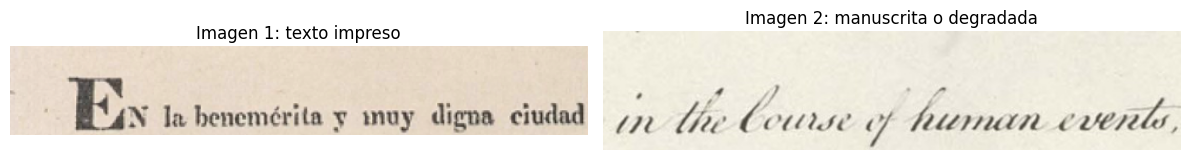

In [13]:
figura, ejes = plt.subplots(1, 2, figsize=(12, 5))

ejes[0].imshow(imagen_impresa)
ejes[0].set_title("Imagen 1: texto impreso")
ejes[0].axis("off")

ejes[1].imshow(imagen_mano)
ejes[1].set_title("Imagen 2: manuscrita o degradada")
ejes[1].axis("off")

plt.tight_layout()
plt.show()

### Registro opcional de consulta a un LLM

Si le pidieron ayuda a un LLM para escribir o corregir código, dejen trazabilidad aquí:

* **Consulta exacta que realizaron:**
* **Respuesta resumida del LLM:**
* **Qué parte decidieron aceptar:**
* **Qué parte decidieron verificar antes de ejecutar:**
* **Qué fuente usaron para validar:**

In [ ]:
!pip install -U transformers accelerate sentencepiece

In [14]:
import torch
from PIL import Image
from transformers import TrOCRProcessor, VisionEncoderDecoderModel

nombre_modelo = "microsoft/trocr-base-handwritten"

processor_ocr = TrOCRProcessor.from_pretrained(nombre_modelo)
modelo_ocr = VisionEncoderDecoderModel.from_pretrained(nombre_modelo)

dispositivo = "cuda" if torch.cuda.is_available() else "cpu"
modelo_ocr.to(dispositivo)
modelo_ocr.eval()

print("✓ Modelo manuscrito cargado")

preprocessor_config.json:   0%|          | 0.00/224 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/4.17k [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/1.12k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

...

model.safetensors:   0%|          | 0.00/1.33G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/478 [00:00<?, ?it/s]

[transformers] VisionEncoderDecoderModel LOAD REPORT from: microsoft/trocr-base-handwritten
Key                         | Status  | 
----------------------------+---------+-
encoder.pooler.dense.bias   | MISSING | 
encoder.pooler.dense.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


generation_config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✓ Modelo manuscrito cargado


In [20]:
pixel_values = processor_ocr(
    images=imagen_mano,
    return_tensors="pt"
).pixel_values.to(dispositivo)

with torch.no_grad():
    ids_generados = modelo_ocr.generate(
        pixel_values,
        max_new_tokens=50
    )

texto = processor_ocr.batch_decode(
    ids_generados,
    skip_special_tokens=True
)[0]

print("Texto reconocido:")
print(texto)

Texto reconocido:
in the course of human events .


In [21]:
pixel_values = processor_ocr(
    images=imagen_impresa,
    return_tensors="pt"
).pixel_values.to(dispositivo)

with torch.no_grad():
    ids_generados = modelo_ocr.generate(
        pixel_values,
        max_new_tokens=50
    )

texto = processor_ocr.batch_decode(
    ids_generados,
    skip_special_tokens=True
)[0]

print("Texto reconocido:")
print(texto)

Texto reconocido:
" EN to benemarita y may digna ciudad


### Registro comparativo de resultados

Completen una tabla comparativa con estos campos:

| Imagen | Tipo de documento | Texto esperado | Texto reconocido | Error observado | Hipótesis sobre el error |
| :--- | :--- | :--- | :--- | :--- | :--- |
| Imagen 1 | [Completar] | [Completar] | [Completar] | [Completar] | [Completar] |
| Imagen 2 | [Completar] | [Completar] | [Completar] | [Completar] | [Completar] |

In [23]:
def reconocer_texto(imagen, nombre_imagen):
    pixel_values = processor_ocr(
        images=imagen,
        return_tensors="pt"
    ).pixel_values.to(dispositivo)

    with torch.no_grad():
        ids_generados = modelo_ocr.generate(
            pixel_values,
            max_new_tokens=50
        )

    texto = processor_ocr.batch_decode(
        ids_generados,
        skip_special_tokens=True
    )[0]

    print(f"Texto reconocido en {nombre_imagen}:")
    print(texto)
    print("-" * 50)

    return texto

In [24]:
texto_impreso = reconocer_texto(imagen_impresa, "imagen impresa")
texto_mano = reconocer_texto(imagen_mano, "imagen manuscrita/degradada")

Texto reconocido en imagen impresa:
" EN to benemarita y may digna ciudad
--------------------------------------------------
Texto reconocido en imagen manuscrita/degradada:
in the course of human events .
--------------------------------------------------


In [29]:
texto_esperado_impreso = "EN LA BENEMÉRITA Y MUY DIGNA CIUDAD"
texto_esperado_mano = "IN THE COURSE OF HUMAN EVENTS"

In [31]:
import pandas as pd

tabla_resultados = pd.DataFrame([
    {
        "Imagen": "Imagen 1",
        "Tipo de documento": "Texto impreso",
        "Texto esperado": texto_esperado_impreso,
        "Texto reconocido": texto_impreso,
        "Error observado": "El modelo no reconoce correctamente todo el contenido impreso o devuelve una salida incompleta.",
        "Hipótesis sobre el error": "El modelo elegido está orientado a texto manuscrito, por lo que puede tener peor desempeño con texto impreso."
    },
    {
        "Imagen": "Imagen 2",
        "Tipo de documento": "Texto manuscrito o degradado",
        "Texto esperado": texto_esperado_mano,
        "Texto reconocido": texto_mano,
        "Error observado": "El modelo transcribió correctamente el texto de la imagen",
        "Hipótesis sobre el error": "n/a"
    }
])

tabla_resultados

,Imagen,Tipo de documento,Texto esperado,Texto reconocido,Error observado,Hipótesis sobre el error
0,Imagen 1,Texto impreso,EN LA BENEMÉRITA Y MUY DIGNA CIUDAD,""" EN to benemarita y may digna ciudad",El modelo no reconoce correctamente todo el co...,El modelo elegido está orientado a texto manus...
1,Imagen 2,Texto manuscrito o degradado,IN THE COURSE OF HUMAN EVENTS,in the course of human events .,El modelo transcribió correctamente el texto d...,n/a


### Extensión optativa: medición con CER o WER

Si quieren profundizar, comparen el texto reconocido contra un texto de referencia. No hace falta resolver una evaluación exhaustiva, pero sí vale la pena experimentar con una métrica simple para cuantificar diferencias.

Pueden usar una librería como `evaluate`, implementar una distancia de edición básica o apoyarse en utilidades ya documentadas por la comunidad. Si toman esta ruta, registren también la fuente que usaron para entender la métrica.

## Consigna de Lectura e Interpretación

1. ¿El modelo respondió mejor al texto impreso o al manuscrito?
2. ¿Qué tipo de error apareció con mayor frecuencia: omisión, sustitución, segmentación o ruido?
3. ¿La limitación que observaron parece venir del modelo, de la calidad de la imagen o de la tarea elegida?
4. Si mañana tuvieran que implementar OCR en un desarrollo real, ¿usarían este mismo enfoque sin cambios? ¿Qué revisarían antes?

## Movimiento 3 - ¿Qué aprendí sobre cómo aprender?

**Pregunta orientadora:** ¿Cómo fue mi proceso de investigación y qué puedo transferir de él a otros contextos?

Este último movimiento es metacognitivo. No se trata solo de evaluar OCR, sino de explicitar cómo investigaron, qué decisiones tomaron y qué hábitos conviene conservar para futuros problemas técnicos.

### Preguntas de reflexión final

Respondan de manera fundamentada:

1. ¿Qué fuentes resultaron más confiables para este tipo de verificación técnica? ¿Por qué?
2. ¿Qué criterios usaron para distinguir información válida de información incorrecta, imprecisa o desactualizada?
3. ¿Qué rol cumplió el LLM en su proceso? ¿En qué momento fue útil y en qué momento se volvió un obstáculo?
4. ¿Qué harían distinto la próxima vez que investiguen un tema técnico nuevo?
5. ¿Qué aprendieron sobre investigación técnica que puedan transferir a otros desarrollos fuera de OCR?

## Cierre del laboratorio

En este cuaderno no buscamos solamente que un modelo lea texto desde una imagen. Buscamos, sobre todo, que ustedes practiquen una forma de trabajo más rigurosa frente a la abundancia de información técnica disponible.

Una parte importante de la formación actual en IA no consiste en memorizar herramientas, sino en desarrollar criterio para investigar, verificar y decidir. Si este cuaderno funcionó bien, entonces no solo aprendieron algo sobre OCR: también fortalecieron una metodología de trabajo transferible a cualquier tecnología nueva que aparezca en su recorrido profesional.

## Rúbrica de evaluación

| Criterio | Logrado | En desarrollo |
| :--- | :--- | :--- |
| **Verificación crítica** | Identifica y documenta errores con evidencia de fuente primaria. Distingue entre incorrecto, impreciso y desactualizado. | Identifica algunos errores pero sin evidencia de fuente primaria, o no distingue entre tipos de error. |
| **Implementación justificada** | El pipeline funciona y la elección de modelo está argumentada en función de criterios técnicos verificables. | El pipeline funciona pero la elección de modelo no está justificada o se apoya solo en el texto original no verificado. |
| **Reflexión metacognitiva** | La reflexión final articula aprendizajes transferibles sobre el proceso de investigación, no solo sobre OCR. | La reflexión existe pero se limita a describir lo que se hizo sin extraer aprendizajes sobre el proceso. |